# Análisis de resultados — Juego de la Vida (CPU vs GPU: CUDA y OpenCL)

Este cuaderno carga los barridos de rendimiento medidos en **Linux** sobre la GPU
sm\_75 (`results/linux/sweep_gpu_opt.csv` y `results/linux/sweep_scaling.csv`),
generados por `scripts/sweep.sh`, y produce las figuras que se incluyen en el
informe (`report/img/bench_*.png`).

**Metodología.** La métrica es *millones de células evaluadas por segundo*
(Mcélulas/s); cada configuración se ejecutó varias veces y se conserva el
**mejor** tiempo (menor ruido de *turbo*/contención). Todas las corridas usan el
`NullRenderer` (sin dibujado ni transferencias en el lazo cronometrado), bordes
acotados y la misma semilla. `mcells_kernel` mide solo el cómputo (eventos CUDA /
eventos de la cola OpenCL / `std::chrono`); `mcells_wall` añade el costo de
lanzamiento por paso. Los tres motores (CPU, CUDA, OpenCL) ejecutan exactamente el
mismo trabajo y se cronometran de la misma forma.

Equipo: Intel Core i7-9750H (6 núcleos / 12 hilos) + NVIDIA GTX 1660 Ti
(GDDR6 192 bits, 288 GB/s). En NVIDIA, OpenCL baja por el mismo backend PTX/SASS
que CUDA, por lo que ambos motores rinden casi igual.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
%matplotlib inline

# Localizar la raíz del repo (funciona desde analysis/ o desde la raíz).
ROOT = Path.cwd()
while not (ROOT / 'results' / 'linux' / 'sweep_gpu_opt.csv').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
RES, IMG = ROOT / 'results' / 'linux', ROOT / 'report' / 'img'
IMG.mkdir(parents=True, exist_ok=True)

# Datos del barrido en Linux (GPU sm_75). utf-8-sig tolera un BOM si el CSV
# se hubiera generado en Windows (PowerShell Set-Content -Encoding utf8).
opt = pd.read_csv(RES / 'sweep_gpu_opt.csv', encoding='utf-8-sig')
scl = pd.read_csv(RES / 'sweep_scaling.csv', encoding='utf-8-sig')

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': True,
                     'grid.alpha': 0.3, 'axes.axisbelow': True})

def best(df, keys, val='mcells_kernel'):
    '''Mejor (máximo) rendimiento por configuración = mejor de las repeticiones.'''
    return df.groupby(keys)[val].max().reset_index()

cpu    = scl[scl.backend == 'cpu']
cuda   = scl[scl.backend == 'cuda']
opencl = scl[scl.backend == 'opencl']
print('opt:', opt.shape, '| scaling:', scl.shape,
      '| N:', sorted(scl.rows.unique()),
      '| backends:', sorted(scl.backend.unique()))

opt: (700, 12) | scaling: (344, 12) | N: [np.int64(64), np.int64(128), np.int64(256), np.int64(512), np.int64(1024), np.int64(2048), np.int64(4096), np.int64(8192), np.int64(16384)] | backends: ['cpu', 'cuda', 'opencl']


## 1. CUDA y OpenCL: tamaño de bloque y memoria local/compartida

Las dos optimizaciones del enunciado, ahora para **ambos motores GPU** (paneles
izquierdo CUDA, derecho OpenCL). La curva por **tamaño de bloque / work-group** es
cóncava en los dos: con 32 hilos hay muy pocos *warps* por SM para ocultar la
latencia de memoria, y con 512 la ocupación cae; el óptimo está en **64–128**. La
**memoria local/compartida** (líneas discontinuas) queda *sistemáticamente por
debajo* de la versión global —cerca de la mitad del rendimiento (penalización
~1,8–2,1×)— porque para un *stencil* de 1 byte la caché L2 ya sirve la
reutilización, y la barrera de grupo, el halo y los accesos byte-a-byte a la SRAM
cuestan más de lo que ahorran.

**OpenCL reproduce el mismo patrón que CUDA** —en NVIDIA baja por el mismo backend
PTX/SASS— con un máximo de **~37 Gcélulas/s** frente a **~35** de CUDA. (Nota: el
*default* `BEST_OPENCL_SHARED` del barrido se había fijado a partir de una corrida
en Windows, donde la memoria local *parecía* ayudar; en Linux, con el camino
OpenCL sano, perjudica igual que en CUDA, así que se corrigió a 0.)


=== CUDA ===
 rows  mejor_blk_glob  Gcel_glob  mejor_blk_shar  Gcel_shar  global/local
  256             128       12.3             128        9.3          1.32
  512             128       26.1             128       16.4          1.58
 1024              64       31.6             128       17.9          1.76
 2048              64       32.7             256       17.1          1.92
 4096             128       35.2             128       17.1          2.06
 8192             128       26.7             128       14.1          1.90
16384              64       25.7             128       13.9          1.85

=== OPENCL ===
 rows  mejor_blk_glob  Gcel_glob  mejor_blk_shar  Gcel_shar  global/local
  256             128       13.1             128        9.6          1.36
  512             128       28.5             128       17.0          1.68
 1024              64       32.6             128       18.2          1.80
 2048              64       36.2             128       19.1          1.90
 4096   

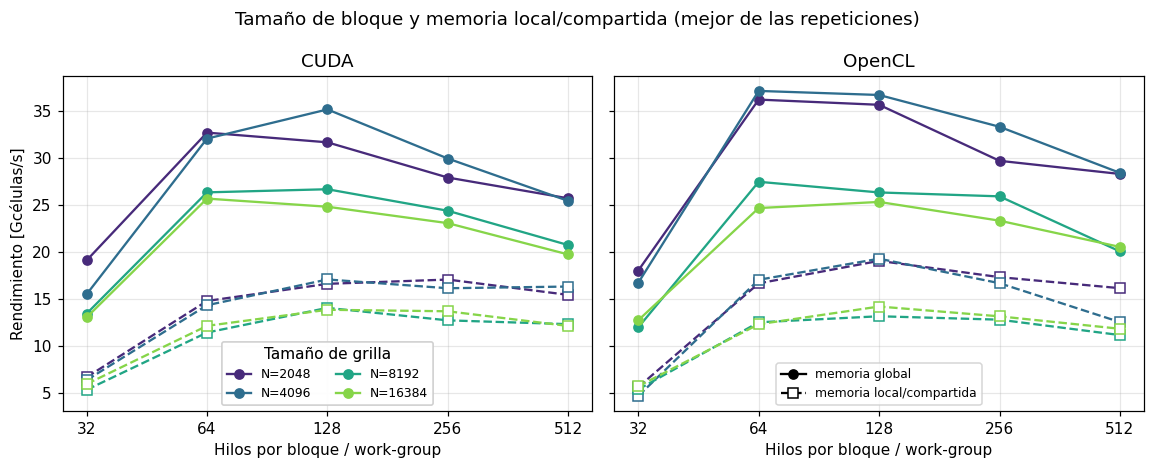

In [2]:
ob = best(opt, ['backend', 'rows', 'block', 'shared'])
ob['G'] = ob.mcells_kernel / 1000.0          # Gcélulas/s

Ns = [2048, 4096, 8192, 16384]
colors = plt.cm.viridis(np.linspace(0.12, 0.82, len(Ns)))
fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.3), sharey=True)
for ax, eng in zip(axes, ['cuda', 'opencl']):
    for n, c in zip(Ns, colors):
        g = ob[(ob.backend == eng) & (ob.rows == n) & (ob.shared == 0)].sort_values('block')
        s = ob[(ob.backend == eng) & (ob.rows == n) & (ob.shared == 1)].sort_values('block')
        ax.plot(g.block, g.G, '-o', color=c, label=f'N={n}')
        ax.plot(s.block, s.G, '--s', color=c, mfc='white')
    ax.set_xscale('log', base=2)
    ax.set_xticks([32, 64, 128, 256, 512]); ax.set_xticklabels([32, 64, 128, 256, 512])
    ax.set_xlabel('Hilos por bloque / work-group')
    ax.set_title({'cuda': 'CUDA', 'opencl': 'OpenCL'}[eng])
axes[0].set_ylabel('Rendimiento [Gcélulas/s]')
leg1 = axes[0].legend(title='Tamaño de grilla', fontsize=8, loc='lower center', ncol=2)
axes[0].add_artist(leg1)
style = [Line2D([], [], color='k', ls='-', marker='o', label='memoria global'),
         Line2D([], [], color='k', ls='--', marker='s', mfc='white', label='memoria local/compartida')]
axes[1].legend(handles=style, fontsize=8, loc='lower center')
fig.suptitle('Tamaño de bloque y memoria local/compartida (mejor de las repeticiones)')
fig.tight_layout(); fig.savefig(IMG / 'bench_block_shared.png', dpi=150, bbox_inches='tight')

# Resumen numérico (global vs local/compartida, mejor bloque por N y motor).
for eng in ['cuda', 'opencl']:
    sub = ob[ob.backend == eng]
    gbest = sub[sub.shared == 0].loc[sub[sub.shared == 0].groupby('rows').G.idxmax()]
    sbest = sub[sub.shared == 1].loc[sub[sub.shared == 1].groupby('rows').G.idxmax()]
    tab = gbest.merge(sbest, on='rows', suffixes=('_glob', '_shar'))
    tab['global/local'] = (tab.G_glob / tab.G_shar).round(2)
    print(f'\n=== {eng.upper()} ===')
    print(tab[['rows', 'block_glob', 'G_glob', 'block_shar', 'G_shar', 'global/local']]
          .rename(columns={'block_glob': 'mejor_blk_glob', 'G_glob': 'Gcel_glob',
                           'block_shar': 'mejor_blk_shar', 'G_shar': 'Gcel_shar'})
          .round({'Gcel_glob': 1, 'Gcel_shar': 1}).to_string(index=False))

## 2. CPU: escalamiento por número de hilos

El reparto por bandas de filas escala **casi linealmente hasta los 6 núcleos
físicos** (~5,4× con 6 hilos). El *hyperthreading* aporta poco (12 hilos ≈ 5,9×):
el problema está limitado por cómputo, no por los núcleos lógicos.

El detalle más llamativo es la **caída no monótona en 8 y 10 hilos**: 8 hilos
rinde *menos* que 6. Con 8 hilos, 2 de los 6 núcleos físicos ejecutan 2 hilos HT
(cada uno ~0,65× de velocidad) y 4 ejecutan 1 hilo; como la `std::barrier`
sincroniza cada generación, **el paso espera al hilo más lento**, y los núcleos
con HT se vuelven el cuello de botella. Con 12 hilos todos los núcleos están
igualmente cargados (2 HT cada uno), el reparto vuelve a ser balanceado y el
rendimiento se recupera. (No es térmico: el calentamiento haría caer también a
10 y 12 hilos, y ahí se recupera.)

threads    1     2      4      6      8      10     12
rows                                                  
64       28.1  54.1  100.2   77.1   88.5  100.5  101.5
128      28.2  54.7  100.5  125.4   95.0  122.4  136.7
256      28.7  56.2  106.6  151.0   97.7  127.3  156.1
512      28.1  54.1  104.5  150.5  104.1  128.9  156.8
1024     27.6  54.0  100.6  148.0  107.8  132.0  155.7
2048     26.8  51.8  100.7  143.1  108.8  131.5  140.1
4096     24.6  50.8   98.7  142.9  115.5  131.0  141.2
8192     26.0  50.1   97.5  141.1  124.0  131.8  145.4
16384     NaN  49.0   93.8  139.5  128.4  139.8  151.5

speed-up paralelo vs 1 hilo (N=4096):  t1=1.0x, t2=2.1x, t4=4.0x, t6=5.8x, t8=4.7x, t10=5.3x, t12=5.7x


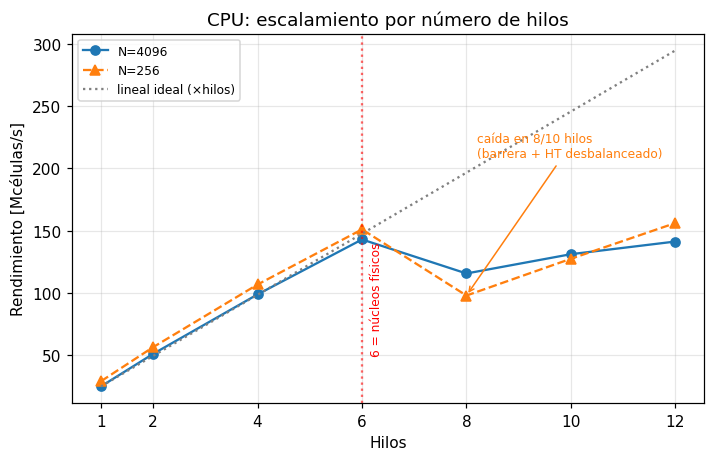

In [3]:
cb = best(cpu, ['rows', 'threads'])
fig, ax = plt.subplots(figsize=(6.6, 4.3))
for n, sty in [(4096, '-o'), (256, '--^')]:
    d = cb[cb.rows == n].sort_values('threads')
    ax.plot(d.threads, d.mcells_kernel, sty, label=f'N={n}')

d4 = cb[cb.rows == 4096].sort_values('threads')
base = float(d4[d4.threads == 1].mcells_kernel.iloc[0])
ax.plot(d4.threads, base * d4.threads, ':', color='grey', label='lineal ideal (×hilos)')
ax.axvline(6, color='red', ls=':', alpha=0.6)
ax.text(6.15, base * 2.0, '6 = núcleos físicos', color='red', fontsize=8, rotation=90, va='bottom')
ax.annotate('caída en 8/10 hilos\n(barrera + HT desbalanceado)',
            xy=(8, float(cb[(cb.rows==256)&(cb.threads==8)].mcells_kernel.iloc[0])),
            xytext=(8.2, base * 8.5), fontsize=8, color='C1',
            arrowprops=dict(arrowstyle='->', color='C1'))
ax.set_xticks([1, 2, 4, 6, 8, 10, 12])
ax.set_xlabel('Hilos'); ax.set_ylabel('Rendimiento [Mcélulas/s]')
ax.set_title('CPU: escalamiento por número de hilos')
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(IMG / 'bench_cpu_threads.png', dpi=150, bbox_inches='tight')

piv = cb.pivot(index='rows', columns='threads', values='mcells_kernel').round(1)
print(piv.to_string())
print('\nspeed-up paralelo vs 1 hilo (N=4096): ',
      ', '.join(f't{int(t)}={piv.loc[4096, t] / piv.loc[4096, 1]:.1f}x' for t in piv.columns))

## 3. CPU vs GPU según el tamaño de grilla

En ejes log–log: la CPU secuencial es **plana** (~27 Mcélulas/s, limitada por
cómputo), la paralela se estabiliza en ~150 Mcélulas/s, y **ambas GPU dominan por
dos a tres órdenes de magnitud**. CUDA y OpenCL son **prácticamente indistinguibles**
—sus curvas de *kernel* se superponen—, con el máximo ~35–36 Gcélulas/s en N≈2048;
a partir de ahí el rendimiento decae un poco (la grilla excede la caché L2 y la
reutilización baja).

Las líneas punteadas (`wall`) incluyen el costo de lanzamiento por paso: para
grillas pequeñas se separan del `kernel` (la GPU está infrautilizada, y OpenCL,
cuyo *kernel* es ligeramente más rápido, acusa más el overhead relativo), pero
**aun así superan a la CPU en todo el rango medido** —porque la métrica excluye las
transferencias *host*↔*device*.

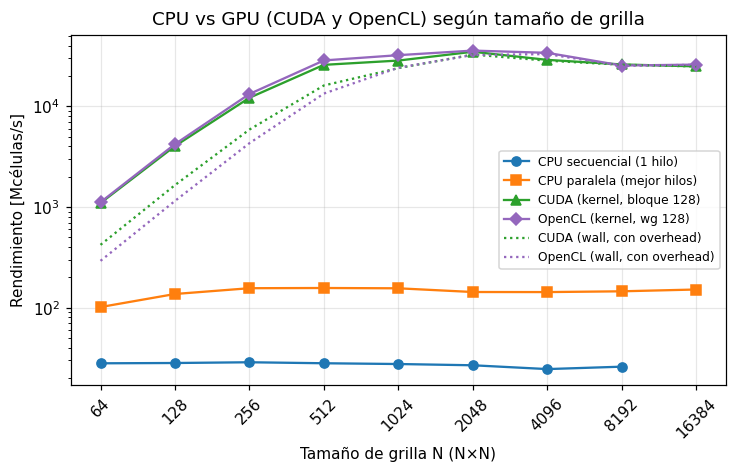

In [4]:
cuda_b = best(cuda, ['rows'])
cuda_w = best(cuda, ['rows'], 'mcells_wall')
ocl_b  = best(opencl, ['rows'])
ocl_w  = best(opencl, ['rows'], 'mcells_wall')
seq_b  = best(cpu[cpu.threads == 1], ['rows'])
par_b  = best(cpu, ['rows'])           # mejor sobre todos los hilos

fig, ax = plt.subplots(figsize=(6.8, 4.4))
ax.plot(seq_b.rows,  seq_b.mcells_kernel,  '-o', color='C0', label='CPU secuencial (1 hilo)')
ax.plot(par_b.rows,  par_b.mcells_kernel,  '-s', color='C1', label='CPU paralela (mejor hilos)')
ax.plot(cuda_b.rows, cuda_b.mcells_kernel, '-^', color='C2', label='CUDA (kernel, bloque 128)')
ax.plot(ocl_b.rows,  ocl_b.mcells_kernel,  '-D', color='C4', label='OpenCL (kernel, wg 128)')
ax.plot(cuda_w.rows, cuda_w.mcells_wall,   ':',  color='C2', label='CUDA (wall, con overhead)')
ax.plot(ocl_w.rows,  ocl_w.mcells_wall,    ':',  color='C4', label='OpenCL (wall, con overhead)')
ax.set_xscale('log', base=2); ax.set_yscale('log')
xs = sorted(cuda_b.rows.unique())
ax.set_xticks(xs); ax.set_xticklabels(xs, rotation=45)
ax.set_xlabel('Tamaño de grilla N (N×N)'); ax.set_ylabel('Rendimiento [Mcélulas/s]')
ax.set_title('CPU vs GPU (CUDA y OpenCL) según tamaño de grilla')
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(IMG / 'bench_cpu_vs_gpu.png', dpi=150, bbox_inches='tight')

## 4. Speed-up y umbral de conveniencia

*Izquierda:* el *speed-up* de la GPU alcanza **~1300× frente a la versión
secuencial** y **~240–250× frente a la mejor CPU paralela** (OpenCL marginalmente
por encima de CUDA), con su máximo en N≈2048. *Derecha:* la eficiencia
`wall/kernel` mide el peso del overhead de lanzamiento; sube de ~26–38 % en N=64 a
~99 % en N≥2048, por lo que la **rodilla** de conveniencia está en **N≈1024–2048**.
OpenCL arranca con eficiencia algo menor (su *kernel* más rápido hace que el
overhead fijo de lanzamiento pese más en términos relativos). Como la métrica no
incluye transferencias, no aparece un umbral por debajo del cual convenga la CPU:
este aparecería al contabilizar el costo PCIe de subir/bajar la grilla.

 rows  cpu_seq  cpu_par  cuda_k   ocl_k  S_par  S_par_ocl  eff  eff_ocl
   64     28.0    101.0  1093.0  1114.0   11.0       11.0 38.5     26.2
  128     28.0    137.0  4020.0  4199.0   29.0       31.0 41.0     27.3
  256     29.0    156.0 12121.0 13212.0   78.0       85.0 48.3     32.5
  512     28.0    157.0 25717.0 28447.0  164.0      181.0 62.4     46.9
 1024     28.0    156.0 28363.0 32080.0  182.0      206.0 84.1     75.1
 2048     27.0    143.0 34680.0 35617.0  242.0      249.0 93.8     90.5
 4096     25.0    143.0 28809.0 33847.0  202.0      237.0 98.2     97.2
 8192     26.0    145.0 25944.0 25328.0  178.0      174.0 99.4     99.3
16384      NaN    152.0 24840.0 25850.0  164.0      171.0 99.8     99.7


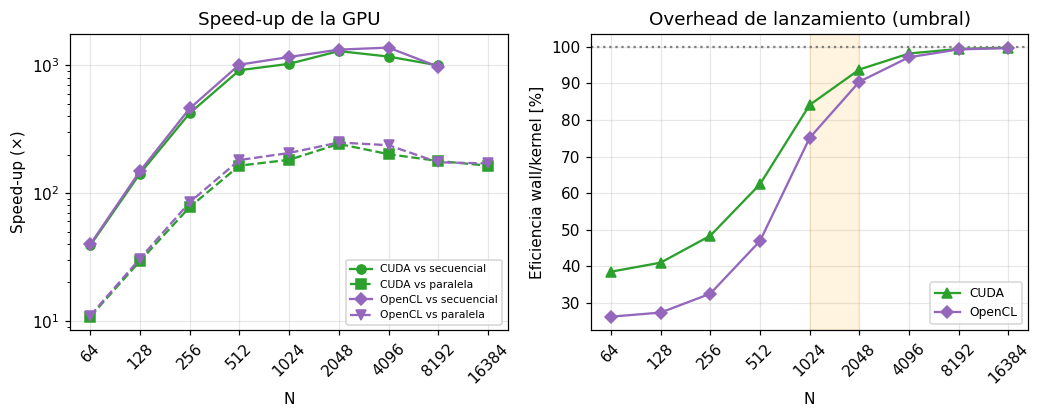

In [5]:
m = cuda_b.rename(columns={'mcells_kernel': 'cuda_k'}).merge(
        cuda_w.rename(columns={'mcells_wall': 'cuda_w'}), on='rows').merge(
        ocl_b.rename(columns={'mcells_kernel': 'ocl_k'}), on='rows').merge(
        ocl_w.rename(columns={'mcells_wall': 'ocl_w'}), on='rows').merge(
        par_b.rename(columns={'mcells_kernel': 'cpu_par'}), on='rows').merge(
        seq_b.rename(columns={'mcells_kernel': 'cpu_seq'}), on='rows', how='left')
m['S_seq']     = m.cuda_k / m.cpu_seq
m['S_par']     = m.cuda_k / m.cpu_par
m['S_seq_ocl'] = m.ocl_k / m.cpu_seq
m['S_par_ocl'] = m.ocl_k / m.cpu_par
m['eff']       = 100 * m.cuda_w / m.cuda_k
m['eff_ocl']   = 100 * m.ocl_w / m.ocl_k

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.6, 3.9))
a1.plot(m.rows, m.S_seq,     '-o',  color='C2', label='CUDA vs secuencial')
a1.plot(m.rows, m.S_par,     '--s', color='C2', label='CUDA vs paralela')
a1.plot(m.rows, m.S_seq_ocl, '-D',  color='C4', label='OpenCL vs secuencial')
a1.plot(m.rows, m.S_par_ocl, '--v', color='C4', label='OpenCL vs paralela')
a1.set_xscale('log', base=2); a1.set_yscale('log')
a1.set_xlabel('N'); a1.set_ylabel('Speed-up (×)'); a1.set_title('Speed-up de la GPU')
a1.legend(fontsize=7)

a2.plot(m.rows, m.eff,     '-^', color='C2', label='CUDA')
a2.plot(m.rows, m.eff_ocl, '-D', color='C4', label='OpenCL')
a2.axhline(100, ls=':', color='grey')
a2.axvspan(1024, 2048, color='orange', alpha=0.12)
a2.set_xscale('log', base=2)
a2.set_xlabel('N'); a2.set_ylabel('Eficiencia wall/kernel [%]')
a2.set_title('Overhead de lanzamiento (umbral)')
a2.legend(fontsize=8)
for a in (a1, a2):
    a.set_xticks(m.rows); a.set_xticklabels(m.rows, rotation=45)
fig.tight_layout(); fig.savefig(IMG / 'bench_speedup.png', dpi=150, bbox_inches='tight')

print(m[['rows', 'cpu_seq', 'cpu_par', 'cuda_k', 'ocl_k', 'S_par', 'S_par_ocl', 'eff', 'eff_ocl']]
      .round({'cpu_seq': 0, 'cpu_par': 0, 'cuda_k': 0, 'ocl_k': 0,
              'S_par': 0, 'S_par_ocl': 0, 'eff': 1, 'eff_ocl': 1})
      .to_string(index=False))

## Resumen

- **Memoria local/compartida:** contraproducente para este *stencil* de 1 byte
  (~0,5× del rendimiento global, penalización ~1,8–2,1×) **en CUDA y en OpenCL**.
  Confirma la predicción del modelo *roofline*.
- **Tamaño de bloque / work-group:** óptimo en 64–128; curva cóncava por ocupación.
- **CPU:** escala hasta 6 núcleos físicos; HT aporta poco y desbalancea la barrera
  en 8/10 hilos.
- **GPU:** ~35 Gcélulas/s máx. en CUDA y ~37 en OpenCL; en NVIDIA OpenCL **iguala a
  CUDA** porque baja por el mismo backend PTX/SASS.
- **Speed-up:** hasta ~240–250× sobre la mejor CPU paralela (y ~1300× sobre la
  secuencial); la GPU conviene desde grillas pequeñas (excluyendo transferencias),
  con la rodilla de eficiencia en N≈1024–2048.